In [13]:
!pip install librosa
!pip install tensorflow
!pip install tflite-runtime


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/350.8 MB 2.4 MB/s eta 0:02:27
   ---------------------------------------- 0.4/350.8 MB 4.9 MB/s eta 0:01:13
   ---------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement tflite-runtime (from versions: none)
ERROR: No matching distribution found for tflite-runtime

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import os
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

In [15]:
DATA_PATH = "C:\\ML_MCA\\wildlife-audio-project\\data\\train_soundscapes"

Checking Species Folders


In [16]:
species_list = os.listdir(DATA_PATH)

print("Number of species:", len(species_list))
print(species_list[:10])

Number of species: 10658
['BC2026_Train_0001_S08_20250606_030007.ogg', 'BC2026_Train_0002_S08_20250607_030007.ogg', 'BC2026_Train_0003_S08_20250607_070007.ogg', 'BC2026_Train_0004_S08_20250607_070007.ogg', 'BC2026_Train_0005_S08_20250607_070007.ogg', 'BC2026_Train_0006_S09_20250828_000000.ogg', 'BC2026_Train_0007_S09_20250829_000000.ogg', 'BC2026_Train_0008_S09_20250831_000000.ogg', 'BC2026_Train_0009_S09_20250828_000000.ogg', 'BC2026_Train_0010_S09_20250828_000000.ogg']


Loading One Audio File

In [17]:
# Select first audio file
audio_file = os.path.join(DATA_PATH, species_list[0])

# Load audio
audio, sr = librosa.load(audio_file)

print("Audio file:", audio_file)
print("Sampling rate:", sr)
print("Audio length:", len(audio))

Audio file: C:\ML_MCA\wildlife-audio-project\data\train_soundscapes\BC2026_Train_0001_S08_20250606_030007.ogg
Sampling rate: 22050
Audio length: 1323000


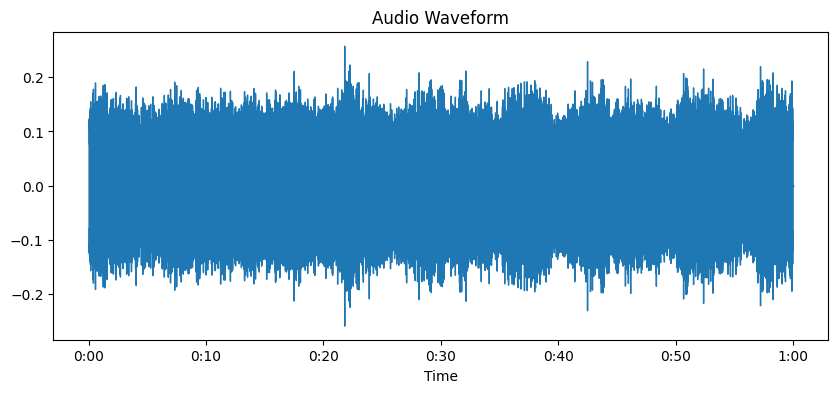

In [18]:
plt.figure(figsize=(10,4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Audio Waveform")
plt.show()

In [19]:
def split_audio(file_path, duration=5, sr=32000):

    audio, sr = librosa.load(file_path, sr=sr)

    samples_per_segment = sr * duration

    segments = []

    for start in range(0, len(audio), samples_per_segment):

        end = start + samples_per_segment

        segment = audio[start:end]

        if len(segment) == samples_per_segment:
            segments.append(segment)

    return segments

In [20]:
segments = split_audio(audio_file)

print("Number of 5-second segments:", len(segments))

Number of 5-second segments: 12


In [21]:
def audio_to_mel(segment, sr=32000):

    mel = librosa.feature.melspectrogram(
        y=segment,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel)

    return mel_db

In [22]:
mel = audio_to_mel(segments[0])

print(mel.shape)

(128, 313)


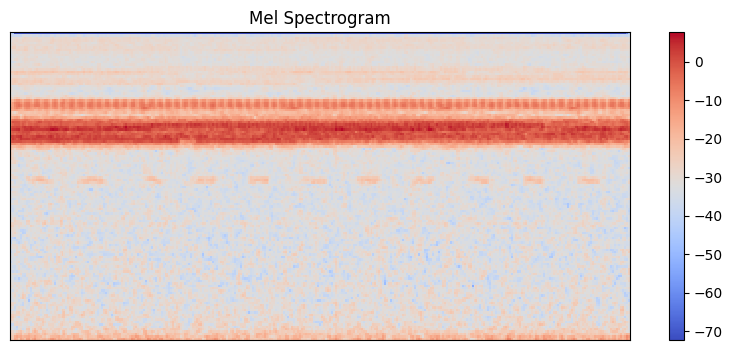

In [23]:
plt.figure(figsize=(10,4))
librosa.display.specshow(mel, sr=32000)
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

In [28]:
# ================================
# Install BirdNET (run once)
# ================================
!pip install birdnetlib


# ================================
# Imports
# ================================
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer
import pandas as pd
import os


# ================================
# Initialize BirdNET
# ================================
analyzer = Analyzer()


# ================================
# Load Metadata (for true labels)
# ================================
METADATA_PATH = r"C:\ML_MCA\wildlife-audio-project\data\train.csv"

metadata = pd.read_csv(METADATA_PATH)

# Create filename → label mapping
label_map = dict(zip(metadata["filename"], metadata["primary_label"]))


# ================================
# Accuracy Calculation
# ================================
correct = 0
total = 0

print("\nRunning BirdNET on multiple files...\n")

for file in os.listdir(DATA_PATH):

    if file.endswith(".ogg") or file.endswith(".wav"):

        file_path = os.path.join(DATA_PATH, file)

        # Skip if label not found
        if file not in label_map:
            continue

        true_label = label_map[file]

        try:
            # Run BirdNET
            recording = Recording(analyzer, file_path)
            recording.analyze()

            # Get top prediction
            if len(recording.detections) > 0:
                predicted_label = recording.detections[0]["species"]
            else:
                predicted_label = ""

            # Compare (case-insensitive)
            if true_label.lower() in predicted_label.lower():
                correct += 1

            total += 1

            # Print sample predictions
            print(f"\nFile: {file}")
            print("True Label:", true_label)
            print("Predicted:", predicted_label)

        except Exception as e:
            print(f"Error processing {file}: {e}")

        # Limit to 20 files for speed (you can remove this later)
        if total == 20:
            break


# ================================
# Final Accuracy
# ================================
if total > 0:
    accuracy = correct / total
    print("\n===============================")
    print("BirdNET Accuracy:", round(accuracy, 3))
    print("Total Samples:", total)
    print("===============================")
else:
    print("No valid samples found!")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.

Running BirdNET on multiple files...

No valid samples found!


In [ ]:
# !pip install torchvision

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB 131.3 kB/s eta 0:00:31
   ---------------------------------------- 0.0/4.0 MB 187.9 kB/s eta 0:00:22
    --------------------------------------- 0.1/4.0 MB 393.8 kB/s eta 0:00:11
   -- ------------------------------------- 0.3/4.0 MB 1.2 MB/s eta 0:00:04
   ------ --------------------------------- 0.6/4.0 MB 2.3 MB/s eta 0:00:02
   --------- ------------------------------ 1.0/4.0 MB 3.0 MB/s eta 0:00:02
   ----------- ---------------------------- 1.1/4.0 MB 3.2 MB/s eta 0:00:01
   ------------ --------------------------- 1.3/4.0 MB 3.3 MB/s eta 0:00:01
   -------------- ------------------------- 1.5/4.0 MB 3.4 MB/s eta 0:00:01
   -------------- ----------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\deepa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# # Install (only needed once)
# # !pip install librosa pandas scikit-learn torch torchvision tqdm

# import os
# import librosa
# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split
# from tqdm import tqdm
# import torchvision.models as models

# # -----------------------------
# # Paths
# # -----------------------------
# DATA_PATH = r"C:\ML_MCA\wildlife-audio-project\data\train_soundscapes"
# METADATA_PATH = r"C:\ML_MCA\wildlife-audio-project\data\train_soundscapes_labels.csv"

# # -----------------------------
# # Load Metadata
# # -----------------------------
# metadata = pd.read_csv(METADATA_PATH)

# file_paths = []
# labels = []

# for _, row in metadata.iterrows():

#     file_path = os.path.join(DATA_PATH, row["filename"])

#     if os.path.exists(file_path):
#         file_paths.append(file_path)
#         labels.append(row["primary_label"])

# # -----------------------------
# # Encode Labels
# # -----------------------------
# le = LabelEncoder()
# labels = le.fit_transform(labels)

# num_classes = len(set(labels))

# # -----------------------------
# # Train / Validation Split
# # -----------------------------
# train_paths, val_paths, train_labels, val_labels = train_test_split(
#     file_paths,
#     labels,
#     test_size=0.2,
#     random_state=42
# )

# # -----------------------------
# # Audio Processing Functions
# # -----------------------------
# def split_audio(file_path, duration=5, sr=32000):

#     audio, sr = librosa.load(file_path, sr=sr)

#     samples_per_segment = sr * duration

#     segments = []

#     for start in range(0, len(audio), samples_per_segment):

#         end = start + samples_per_segment

#         segment = audio[start:end]

#         if len(segment) == samples_per_segment:
#             segments.append(segment)

#     return segments


# def audio_to_mel(segment, sr=32000):

#     mel = librosa.feature.melspectrogram(
#         y=segment,
#         sr=sr,
#         n_mels=128
#     )

#     mel = librosa.power_to_db(mel)

#     return mel

# # -----------------------------
# # Dataset Class
# # -----------------------------
# class AudioDataset(Dataset):

#     def __init__(self, file_paths, labels):
#         self.file_paths = file_paths
#         self.labels = labels

#     def __len__(self):
#         return len(self.file_paths)

#     def __getitem__(self, idx):

#         segments = split_audio(self.file_paths[idx])

#         mel = audio_to_mel(segments[0])

#         mel = torch.tensor(mel).float()

#         mel = mel.unsqueeze(0).repeat(3,1,1)   # 3 channels for ResNet

#         label = torch.tensor(self.labels[idx])

#         return mel, label

# # -----------------------------
# # DataLoaders
# # -----------------------------
# train_dataset = AudioDataset(train_paths, train_labels)
# val_dataset = AudioDataset(val_paths, val_labels)

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# # -----------------------------
# # Load ResNet50
# # -----------------------------
# model = models.resnet50(pretrained=True)

# model.fc = nn.Linear(model.fc.in_features, num_classes)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = model.to(device)

# # -----------------------------
# # Training Setup
# # -----------------------------
# criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# # -----------------------------
# # Training Loop
# # -----------------------------
# EPOCHS = 3

# for epoch in range(EPOCHS):

#     model.train()

#     total_loss = 0

#     for x,y in tqdm(train_loader):

#         x = x.to(device)
#         y = y.to(device)

#         outputs = model(x)

#         loss = criterion(outputs,y)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     print("Epoch:",epoch+1,"Loss:",total_loss)

# # -----------------------------
# # Evaluation
# # -----------------------------
# correct = 0
# total = 0

# model.eval()

# with torch.no_grad():

#     for x,y in val_loader:

#         x = x.to(device)
#         y = y.to(device)

#         outputs = model(x)

#         _,pred = torch.max(outputs,1)

#         total += y.size(0)

#         correct += (pred==y).sum().item()

# accuracy = 100 * correct / total

# print("Validation Accuracy:",accuracy)

C:\Users\deepa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\deepa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\deepa/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:27<00:00, 3.72MB/s]
100%|██████████| 148/148 [14:31<00:00,  5.89s/it]


Epoch: 1 Loss: 600.6332478523254


100%|██████████| 148/148 [13:17<00:00,  5.39s/it]


Epoch: 2 Loss: 390.93469166755676


100%|██████████| 148/148 [11:01<00:00,  4.47s/it]


Epoch: 3 Loss: 306.5231006741524
Validation Accuracy: 43.58108108108108
